# 🏠 House Price Prediction using Machine Learning

## Objective
The objective of this project is to build a regression model that predicts house prices based on various property features such as area, bedrooms, bathrooms, location, and construction details.

## Dataset
This dataset contains information about residential properties including house size, number of rooms, location, construction year, and selling price.

## Workflow
- Import Libraries
- Load Dataset
- Exploratory Data Analysis (EDA)
- Data Cleaning
- Feature Engineering
- Model Training
- Model Evaluation
- Residual Analysis
- Save Best Model
- Prediction Example

Import Libraries

In [107]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

Load Dataset

In [108]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("/content/data.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


Basic Exploration

In [109]:
# First 5 Rows
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [110]:
# Last 5 Rows
df.tail()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
4595,2014-07-09 00:00:00,308166.666667,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,534333.333333,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,416904.166667,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,203400.000000,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA
4599,2014-07-10 00:00:00,220600.000000,3.0,2.50,1490,8102,2.0,0,0,4,1490,0,1990,0,18717 SE 258th St,Covington,WA 98042,USA


In [111]:
# Dataset Shape
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 4600
Columns : 18


In [112]:
# Column Names
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [113]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [114]:
# Statistical Summary
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


Check Missing Values

In [115]:
# Missing Values

df.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


Exploratory Data Analysis (EDA)

Check Duplicate Records

In [116]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


Check Data Types

In [117]:
df.dtypes

,0
date,object
price,float64
bedrooms,float64
bathrooms,float64
sqft_living,int64
sqft_lot,int64
floors,float64
waterfront,int64
view,int64
condition,int64


Correlation Between Numerical Features

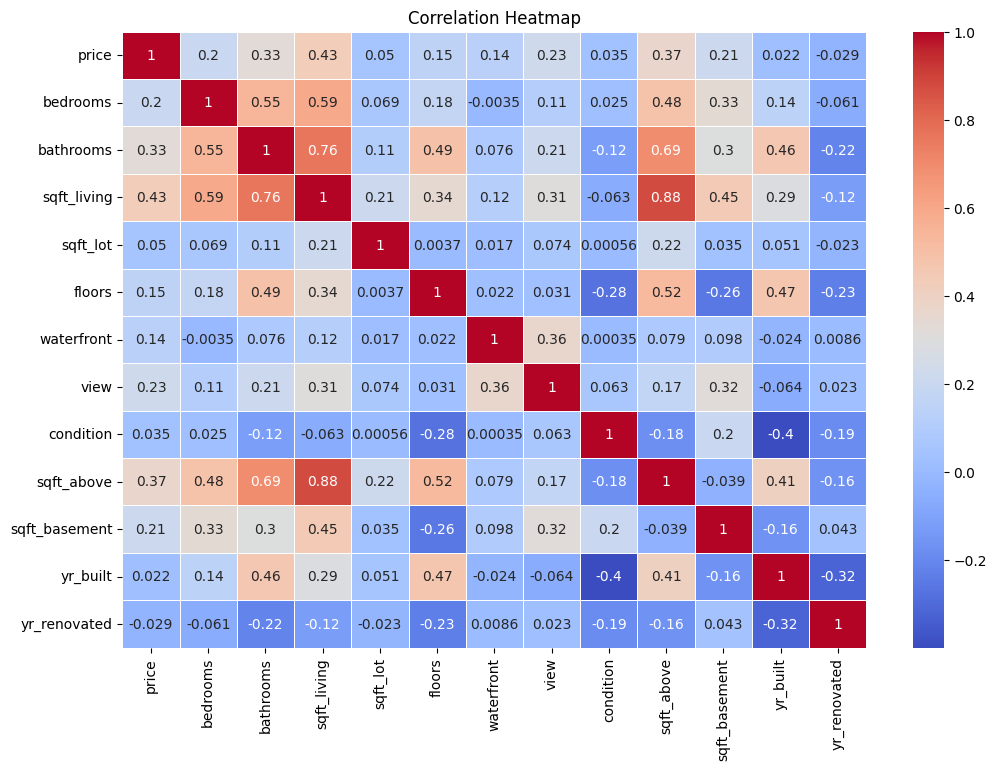

In [118]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

Price Distribution (Histogram)

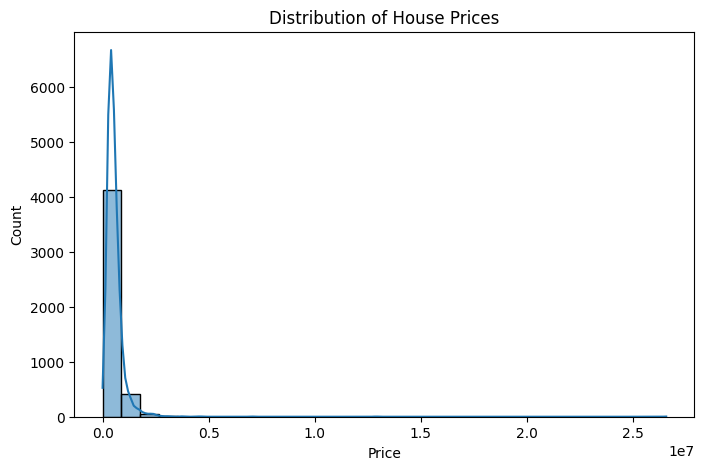

In [119]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

Scatter Plot (Living Area vs Price)

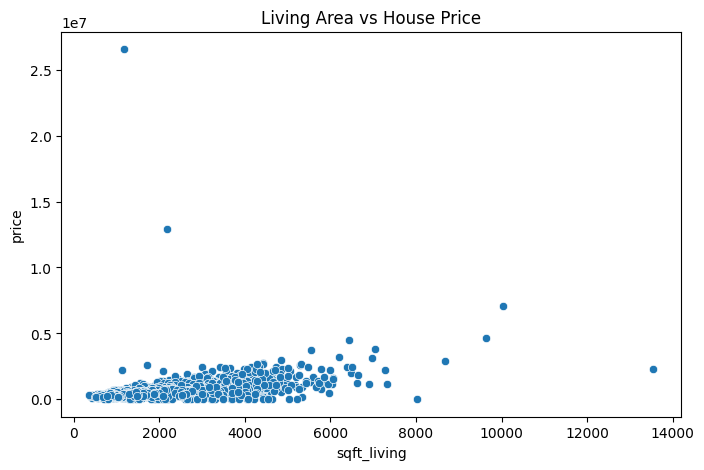

In [120]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="sqft_living",
    y="price",
    data=df
)

plt.title("Living Area vs House Price")

plt.show()

Bedrooms vs Price

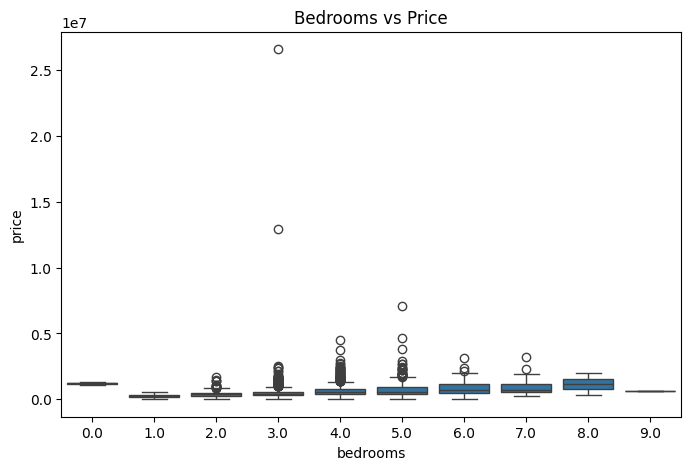

In [121]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="bedrooms",
    y="price",
    data=df
)

plt.title("Bedrooms vs Price")

plt.show()

Bathrooms vs Price

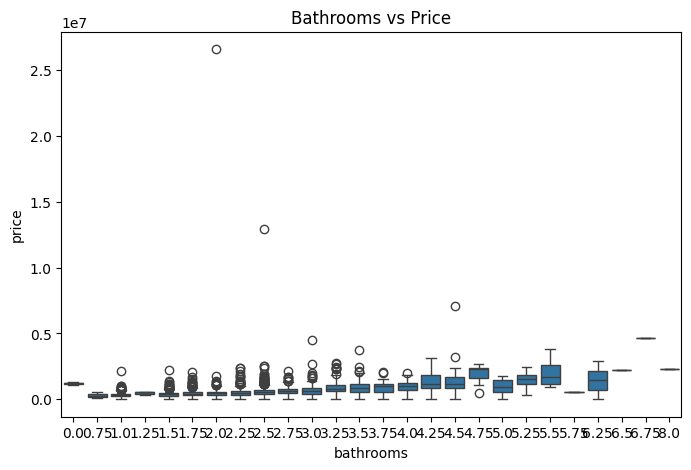

In [122]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="bathrooms",
    y="price",
    data=df
)

plt.title("Bathrooms vs Price")

plt.show()

Floors vs Price

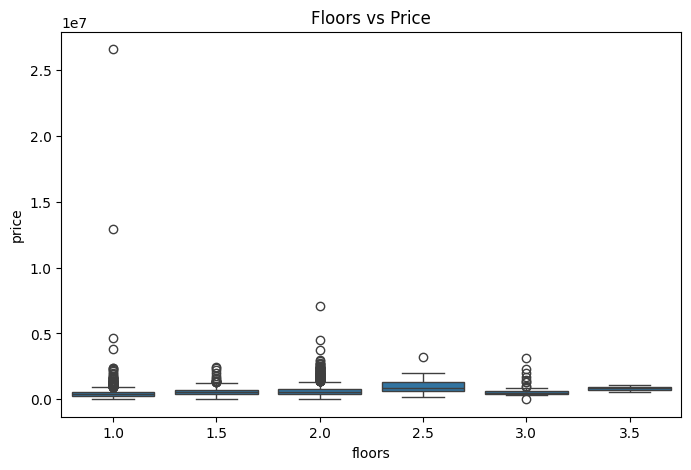

In [123]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="floors",
    y="price",
    data=df
)

plt.title("Floors vs Price")

plt.show()

Pairplot (Optional but Professional)

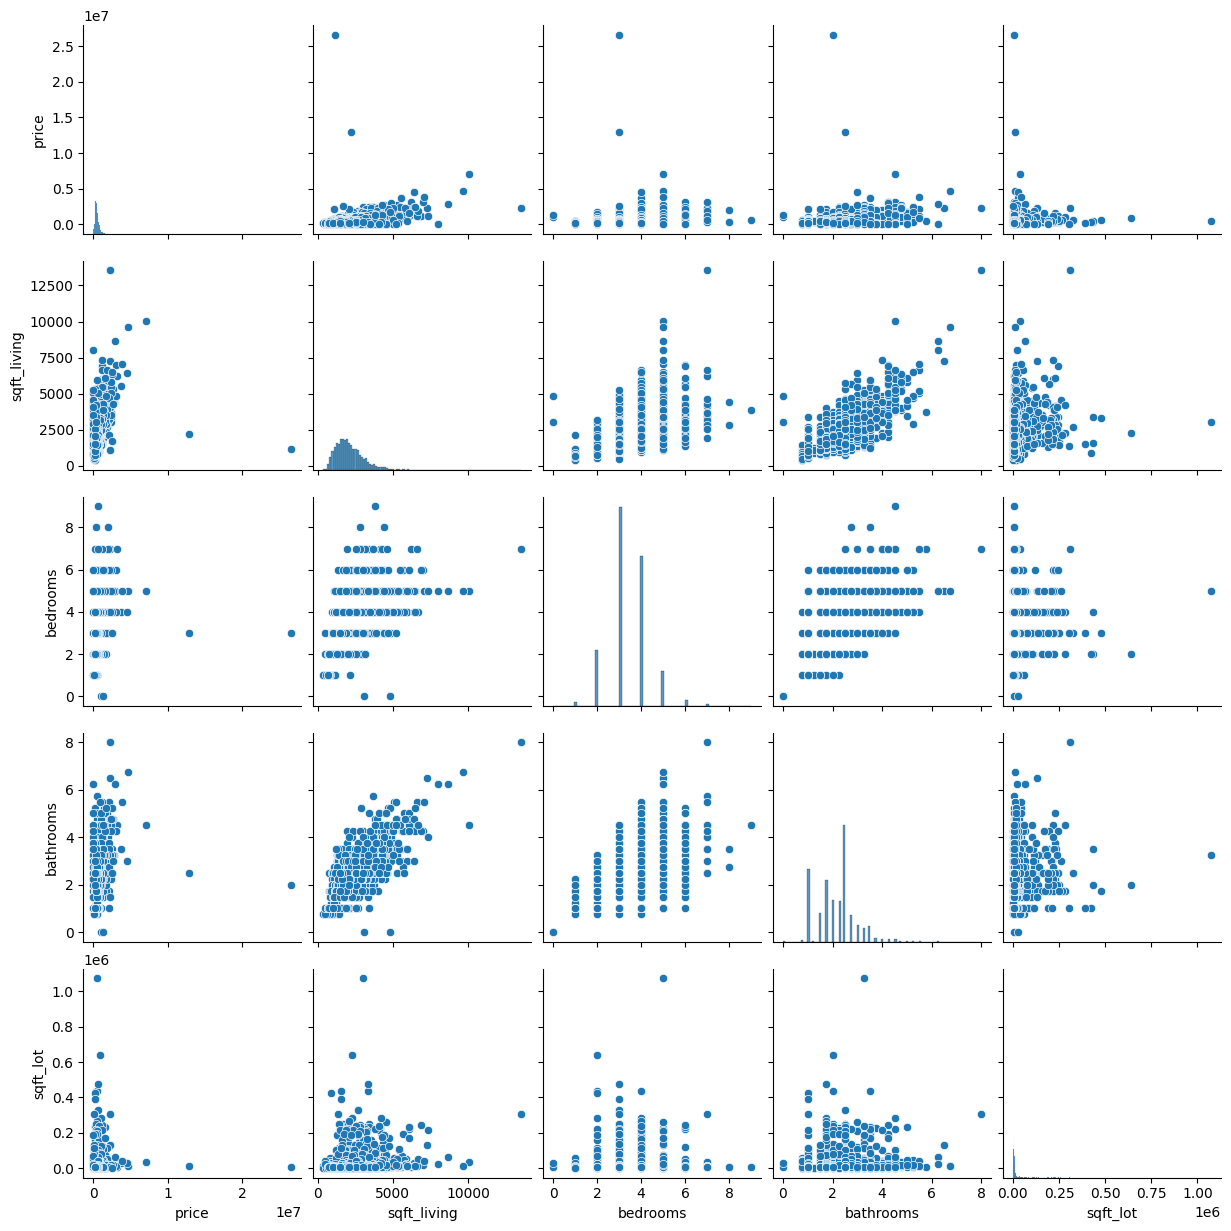

In [124]:
sns.pairplot(
    df[["price",
        "sqft_living",
        "bedrooms",
        "bathrooms",
        "sqft_lot"]]
)

plt.show()

## EDA Summary

- The target variable (price) shows a right-skewed distribution.
- Living area (`sqft_living`) has a strong positive relationship with house price.
- Houses with more bathrooms generally have higher prices.
- The correlation heatmap identifies features that are strongly associated with the target variable.
- Some outliers are visible in the price and living area distributions.
- The dataset contains both numerical and categorical features, which will require preprocessing before model training.

Data Preprocessing & Feature Engineering

Separate Features and Target

In [125]:
# ==========================================
# Separate Features and Target Variable
# ==========================================

X = df.drop("price", axis=1)
y = df["price"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (4600, 17)
Target Shape: (4600,)


Identify Numerical and Categorical Columns

In [126]:
# Numerical and Categorical Columns

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated'],
      dtype='object')

Categorical Features:
Index(['date', 'street', 'city', 'statezip', 'country'], dtype='object')


Convert Date Column

In [127]:
# Convert date into datetime format

X["date"] = pd.to_datetime(X["date"])

# Extract useful information
X["year"] = X["date"].dt.year
X["month"] = X["date"].dt.month
X["day"] = X["date"].dt.day

# Drop original date column
X.drop("date", axis=1, inplace=True)

print("Date column transformed successfully!")

Date column transformed successfully!


Create Preprocessing Pipeline

In [128]:

# Update categorical columns after dropping 'date'
categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns

# Numerical Pipeline
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical Pipeline
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine both pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Train-Test Split

In [129]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples: (3680, 19)
Testing Samples : (920, 19)


Model Training & Evaluation

Import Required Models

In [130]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

Create Pipelines for Each Model

In [131]:
# Linear Regression Pipeline
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Random Forest Pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

# Gradient Boosting Pipeline
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        random_state=42
    ))
])

Train the Models

In [132]:
print("Training Linear Regression...")
lr_pipeline.fit(X_train, y_train)

print("Training Random Forest...")
rf_pipeline.fit(X_train, y_train)

print("Training Gradient Boosting...")
gb_pipeline.fit(X_train, y_train)

print("✅ All models trained successfully!")

Training Linear Regression...
Training Random Forest...
Training Gradient Boosting...
✅ All models trained successfully!


Create an Evaluation Function

In [133]:
def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    r2 = r2_score(y_test, predictions)

    return mae, rmse, r2, predictions

Evaluate Each Model

In [134]:
lr_mae, lr_rmse, lr_r2, lr_pred = evaluate_model(
    lr_pipeline,
    X_test,
    y_test
)

rf_mae, rf_rmse, rf_r2, rf_pred = evaluate_model(
    rf_pipeline,
    X_test,
    y_test
)

gb_mae, gb_rmse, gb_r2, gb_pred = evaluate_model(
    gb_pipeline,
    X_test,
    y_test
)

Compare Model Performance

In [135]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        lr_mae,
        rf_mae,
        gb_mae
    ],

    "RMSE": [
        lr_rmse,
        rf_rmse,
        gb_rmse
    ],

    "R² Score": [
        lr_r2,
        rf_r2,
        gb_r2
    ]
})

results.sort_values(
    by="R² Score",
    ascending=False,
    inplace=True
)

results = results.round(2)

display(results)

,Model,MAE,RMSE,R² Score
2,Gradient Boosting,163776.44,984483.05,0.05
1,Random Forest,156225.95,984773.91,0.05
0,Linear Regression,166313.17,986974.92,0.04


In [136]:
results.to_csv("model_comparison.csv", index=False)

print("Model comparison saved successfully!")

Model comparison saved successfully!


Best Model

In [137]:
best_model_name = results.iloc[0]["Model"]

print("=" * 50)
print("🏆 BEST PERFORMING MODEL")
print("=" * 50)
print(f"Model Name : {best_model_name}")

🏆 BEST PERFORMING MODEL
Model Name : Gradient Boosting


Save the Best Model

In [138]:
if best_model_name == "Linear Regression":
    best_model = lr_pipeline

elif best_model_name == "Random Forest":
    best_model = rf_pipeline

else:
    best_model = gb_pipeline

import joblib

joblib.dump(best_model, "house_price_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


Residual Analysis (Internship Requirement)

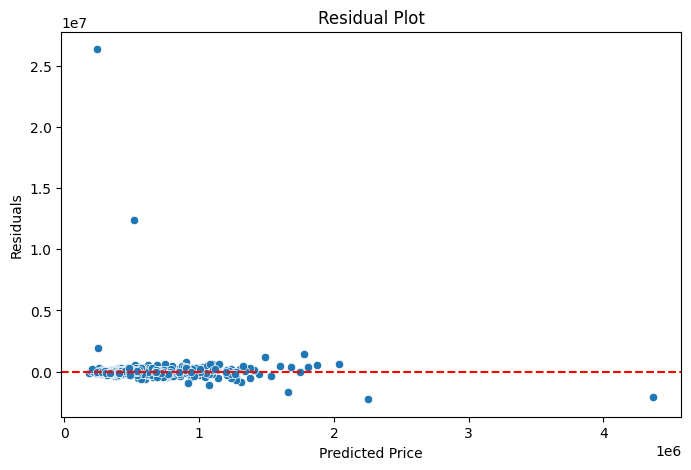

In [139]:
best_predictions = best_model.predict(X_test)

residuals = y_test - best_predictions

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=best_predictions,
    y=residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.show()

Actual vs Predicted Prices

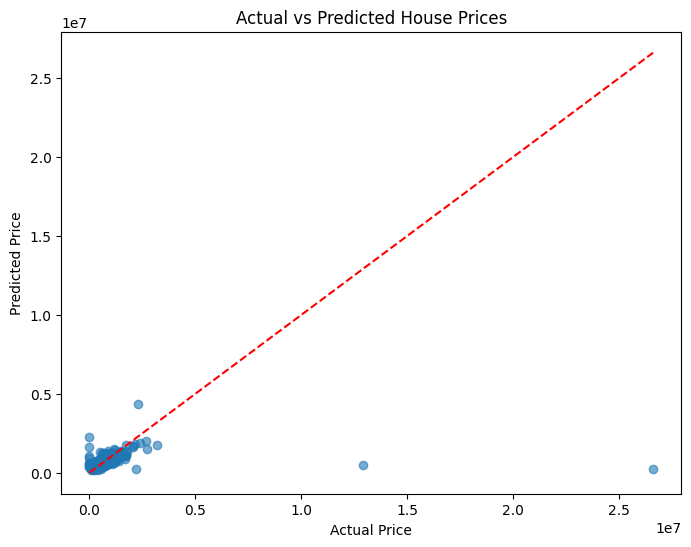

In [140]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

Prediction Example (Required Deliverable)

In [141]:
sample_house = X_test.iloc[[0]]

predicted_price = best_model.predict(sample_house)

print("=" * 50)
print("🏠 HOUSE PRICE PREDICTION")
print("=" * 50)

print(f"Predicted House Price : ₹{predicted_price[0]:,.2f}")
print(f"Actual House Price    : ₹{y_test.iloc[0]:,.2f}")

🏠 HOUSE PRICE PREDICTION
Predicted House Price : ₹425,287.75
Actual House Price    : ₹544,000.00


Notebook Conclusion (Markdown Cell)

# 🎯 Conclusion

This project successfully developed a machine learning regression model to predict house prices using residential property features.

## Project Highlights

- Loaded and explored the dataset
- Performed Exploratory Data Analysis (EDA)
- Checked for missing values and duplicate records
- Applied feature engineering and categorical encoding
- Trained three regression models:
  - Linear Regression
  - Random Forest Regressor
  - Gradient Boosting Regressor
- Evaluated models using MAE, RMSE, and R² Score
- Performed residual analysis
- Selected the best-performing model
- Saved the trained model using Joblib
- Demonstrated prediction on a sample house

This project demonstrates a complete end-to-end machine learning workflow for a regression problem and provides a reusable model for future house price predictions.